In [1]:
# ============================================================
# MODEL COMPARISON
# Enterprise HR AI Platform
# ============================================================

import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# PROJECT PATH SETUP
# ============================================================

CURRENT_DIR = Path.cwd()

PROJECT_ROOT = CURRENT_DIR.parent

FEATURE_ENGINEERED_PATH = (
    PROJECT_ROOT /
    "data" /
    "feature_engineered"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "models"
)

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

print("Current Directory:")
print(CURRENT_DIR)

print("\nProject Root:")
print(PROJECT_ROOT)

print("\nFeature Engineered Path:")
print(FEATURE_ENGINEERED_PATH)

print("\nModel Path:")
print(MODEL_PATH)

Current Directory:
C:\Users\Shubham\Desktop\enterprise_hr_ai\notebooks

Project Root:
C:\Users\Shubham\Desktop\enterprise_hr_ai

Feature Engineered Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\data\feature_engineered

Model Path:
C:\Users\Shubham\Desktop\enterprise_hr_ai\models


In [3]:
# ============================================================
# LOAD EMPLOYEE FEATURE DATA
# ============================================================

employee_file = (
    FEATURE_ENGINEERED_PATH /
    "employee_features.csv"
)

employee_df = pd.read_csv(
    employee_file
)

print("✓ Employee feature dataset loaded.")

print(
    f"\nShape: {employee_df.shape}"
)

display(
    employee_df.head()
)

✓ Employee feature dataset loaded.

Shape: (1470, 47)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,ExperienceGroup,CompanyTenureGroup,OverallSatisfactionScore,SatisfactionCategory,OverTimeRisk,LongCommuteRisk,LowIncomeRisk,FrequentJobChangeRisk,AttritionRiskScore,AttritionRiskCategory
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,6-10 Years,6-10 Years,2.00,Low Satisfaction,High Risk,Lower Risk,Lower Risk,High Risk,5,High Risk
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,6-10 Years,6-10 Years,3.00,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,Lower Risk,0,Low Risk
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,6-10 Years,0-1 Year,3.00,Medium Satisfaction,High Risk,Lower Risk,High Risk,High Risk,4,High Risk
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,6-10 Years,6-10 Years,3.25,High Satisfaction,High Risk,Lower Risk,High Risk,Lower Risk,3,Medium Risk
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,6-10 Years,2-3 Years,2.50,Medium Satisfaction,Lower Risk,Lower Risk,Lower Risk,High Risk,3,Medium Risk


In [4]:
# ============================================================
# CREATE ATTRITION TARGET
# ============================================================

employee_df["AttritionTarget"] = (
    employee_df["Attrition"]
    .map({
        "No": 0,
        "Yes": 1
    })
)

print("Attrition target created.")

display(
    employee_df[
        [
            "Attrition",
            "AttritionTarget"
        ]
    ].head()
)

Attrition target created.


,Attrition,AttritionTarget
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [5]:
# ============================================================
# SELECT MODEL FEATURES
# ============================================================

model_features = [
    "Age",
    "OverTime",
    "JobSatisfaction",
    "MonthlyIncome",
    "YearsAtCompany",
    "WorkLifeBalance",
    "TotalWorkingYears",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "JobLevel",
    "JobInvolvement",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",
    "DistanceFromHome",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "BusinessTravel",
    "Department",
    "EducationField",
    "JobRole",
    "MaritalStatus",
    "Gender",
    "IncomePerYearExperience",
    "CompanyTenureRatio",
    "PromotionWaitRatio",
    "OverallSatisfactionScore",
    "CareerStabilityScore"
]

available_features = [
    feature
    for feature in model_features
    if feature in employee_df.columns
]

missing_features = [
    feature
    for feature in model_features
    if feature not in employee_df.columns
]

print(
    f"Available features: "
    f"{len(available_features)}"
)

if missing_features:
    print("\nMissing features:")
    print(missing_features)
else:
    print("✓ All requested features are available.")

Available features: 26

Missing features:
['IncomePerYearExperience', 'CompanyTenureRatio', 'PromotionWaitRatio', 'CareerStabilityScore']


In [6]:
# ============================================================
# CREATE FEATURE MATRIX AND TARGET
# ============================================================

X = employee_df[
    available_features
].copy()

y = employee_df[
    "AttritionTarget"
].copy()

print("X shape:", X.shape)

print("y shape:", y.shape)

print("\nTarget distribution:")

display(
    y.value_counts()
    .sort_index()
    .to_frame(
        name="Count"
    )
)

X shape: (1470, 26)
y shape: (1470,)

Target distribution:


,Count
0,1233
1,237


In [7]:
# ============================================================
# IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print(
    f"\nTotal numerical features: "
    f"{len(numeric_features)}"
)

print("\nCategorical features:")
print(categorical_features)

print(
    f"\nTotal categorical features: "
    f"{len(categorical_features)}"
)

Numerical features:
['Age', 'JobSatisfaction', 'MonthlyIncome', 'YearsAtCompany', 'WorkLifeBalance', 'TotalWorkingYears', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'JobLevel', 'JobInvolvement', 'EnvironmentSatisfaction', 'RelationshipSatisfaction', 'DistanceFromHome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TrainingTimesLastYear', 'OverallSatisfactionScore']

Total numerical features: 19

Categorical features:
['OverTime', 'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus', 'Gender']

Total categorical features: 7


In [8]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("✓ Preprocessing pipeline created.")

✓ Preprocessing pipeline created.


In [9]:
# ============================================================
# STRATIFIED TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("TRAIN / TEST SPLIT")
print("=" * 70)

print(
    f"Training rows: {len(X_train)}"
)

print(
    f"Testing rows: {len(X_test)}"
)

print("\nTraining target:")
display(
    y_train.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

print("\nTesting target:")
display(
    y_test.value_counts()
    .sort_index()
    .to_frame(name="Count")
)

TRAIN / TEST SPLIT
Training rows: 1176
Testing rows: 294

Training target:


,Count
0,986
1,190



Testing target:


,Count
0,247
1,47


In [10]:
# ============================================================
# MODEL 1 — LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("✓ Logistic Regression pipeline created.")

✓ Logistic Regression pipeline created.


In [11]:
# ============================================================
# MODEL 2 — RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

print("✓ Random Forest pipeline created.")

✓ Random Forest pipeline created.


In [13]:
# ============================================================
# XGBOOST IMPORT — OPTIONAL
# ============================================================

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print("✓ XGBoost is available.")

except Exception:
    XGBOOST_AVAILABLE = False
    print("⚠ XGBoost is unavailable.")
    print("✓ Continuing without XGBoost.")

⚠ XGBoost is unavailable.
✓ Continuing without XGBoost.


In [14]:
# ============================================================
# MODEL DEFINITIONS
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Models selected for comparison:\n")

for name in models:
    print("✓", name)

print("\nXGBoost:", "Included" if XGBOOST_AVAILABLE else "Skipped")

Models selected for comparison:

✓ Logistic Regression
✓ Random Forest

XGBoost: Skipped


In [15]:
# ============================================================
# TRAIN MODELS
# ============================================================

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

    print(f"✓ {name} trained successfully.")

print("\nAll available models trained.")

✓ Logistic Regression trained successfully.
✓ Random Forest trained successfully.

All available models trained.


In [16]:
# ============================================================
# GENERATE PREDICTIONS
# ============================================================

predictions = {}
probabilities = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    print(f"✓ Predictions generated: {name}")

✓ Predictions generated: Logistic Regression
✓ Predictions generated: Random Forest


In [17]:
# ============================================================
# MODEL EVALUATION
# ============================================================

results = []

for name in trained_models:

    y_pred = predictions[name]
    y_prob = probabilities[name]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.629630,0.361702,0.459459,0.818158
1,Random Forest,0.541667,0.276596,0.366197,0.812473


In [18]:
# ============================================================
# MODEL COMPARISON
# ============================================================

print("MODEL COMPARISON")
print("=" * 70)

display(
    results_df.style.format({
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

MODEL COMPARISON


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.6296,0.3617,0.4595,0.8182
1,Random Forest,0.5417,0.2766,0.3662,0.8125


In [19]:
# ============================================================
# SELECT BEST MODEL
# ============================================================

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"🏆 Best Model: {best_model_name}")
print(f"Selection Criterion: ROC-AUC")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

🏆 Best Model: Logistic Regression
Selection Criterion: ROC-AUC
ROC-AUC: 0.8182


In [20]:
# ============================================================
# CLASSIFICATION REPORTS
# ============================================================

for name in trained_models:

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["No Attrition", "Attrition"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

No Attrition       0.89      0.96      0.92       247
   Attrition       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294


Random Forest
              precision    recall  f1-score   support

No Attrition       0.87      0.96      0.91       247
   Attrition       0.54      0.28      0.37        47

    accuracy                           0.85       294
   macro avg       0.71      0.62      0.64       294
weighted avg       0.82      0.85      0.83       294



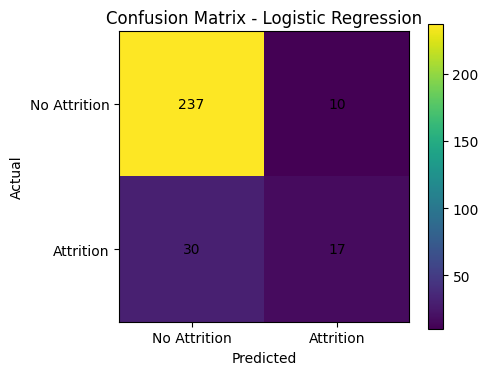

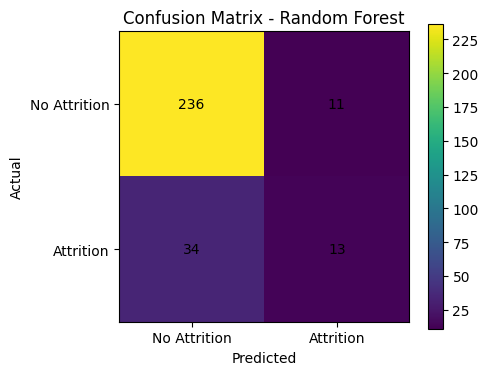

In [21]:
# ============================================================
# CONFUSION MATRICES
# ============================================================

for name in trained_models:

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    plt.figure(figsize=(5, 4))

    plt.imshow(cm)

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.xticks([0, 1], ["No Attrition", "Attrition"])
    plt.yticks([0, 1], ["No Attrition", "Attrition"])

    for i in range(2):
        for j in range(2):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

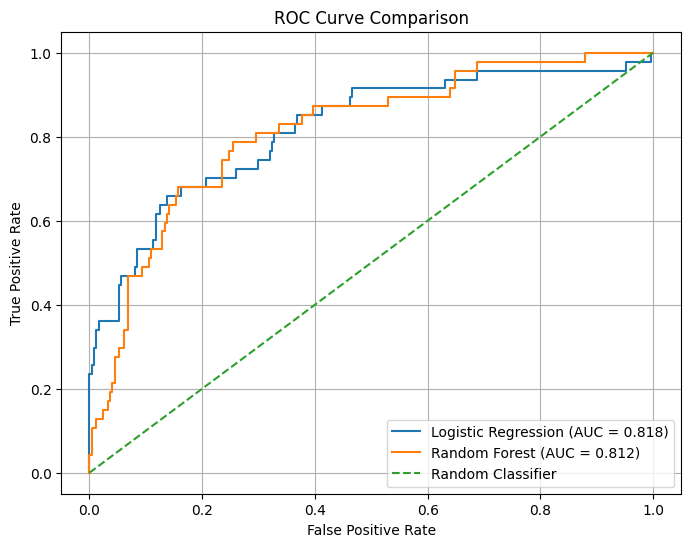

In [22]:
# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(8, 6))

for name in trained_models:

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

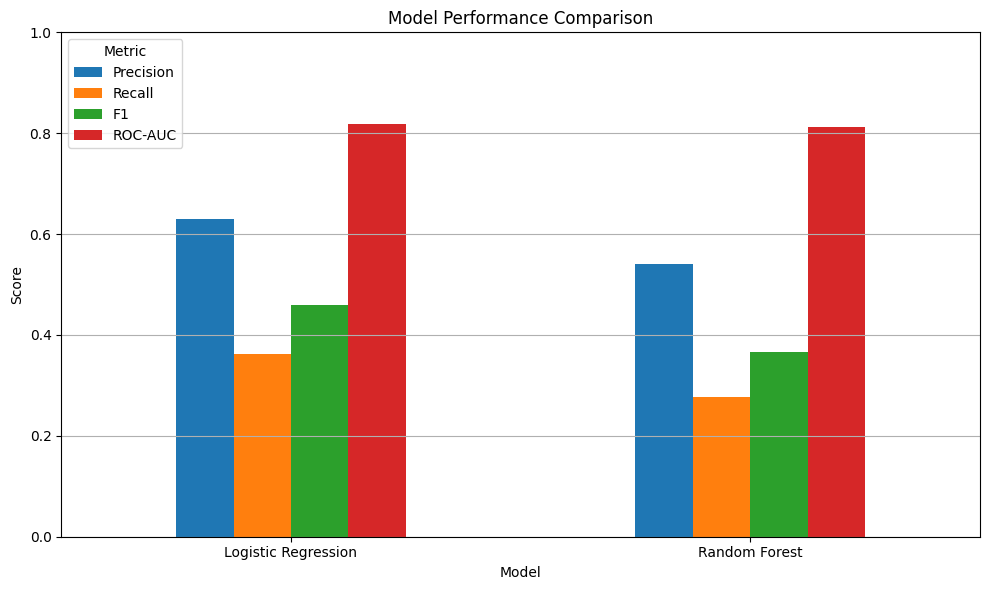

In [23]:
# ============================================================
# METRIC COMPARISON CHART
# ============================================================

metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
]

ax = results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# BEST MODEL METRICS
# ============================================================

best_metrics = results_df[
    results_df["Model"] == best_model_name
].iloc[0]

print("BEST MODEL PERFORMANCE")
print("=" * 50)

print(f"Model     : {best_model_name}")
print(f"Precision : {best_metrics['Precision']:.4f}")
print(f"Recall    : {best_metrics['Recall']:.4f}")
print(f"F1 Score  : {best_metrics['F1']:.4f}")
print(f"ROC-AUC   : {best_metrics['ROC-AUC']:.4f}")

BEST MODEL PERFORMANCE
Model     : Logistic Regression
Precision : 0.6296
Recall    : 0.3617
F1 Score  : 0.4595
ROC-AUC   : 0.8182


In [25]:
# ============================================================
# IMPROVEMENT OVER BASELINE
# ============================================================

baseline_auc = results_df.loc[
    results_df["Model"] == "Logistic Regression",
    "ROC-AUC"
].iloc[0]

best_auc = results_df.iloc[0]["ROC-AUC"]

improvement = best_auc - baseline_auc

print(f"Baseline ROC-AUC : {baseline_auc:.4f}")
print(f"Best ROC-AUC     : {best_auc:.4f}")
print(f"Improvement      : {improvement:+.4f}")

Baseline ROC-AUC : 0.8182
Best ROC-AUC     : 0.8182
Improvement      : +0.0000


In [26]:
# ============================================================
# BEST MODEL PREDICTIONS
# ============================================================

best_predictions = predictions[best_model_name]
best_probabilities = probabilities[best_model_name]

prediction_df = X_test.copy()

prediction_df["ActualAttrition"] = y_test.values
prediction_df["PredictedAttrition"] = best_predictions
prediction_df["AttritionProbability"] = best_probabilities

prediction_df.head()

,Age,OverTime,JobSatisfaction,MonthlyIncome,YearsAtCompany,WorkLifeBalance,TotalWorkingYears,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,BusinessTravel,Department,EducationField,JobRole,MaritalStatus,Gender,OverallSatisfactionScore,ActualAttrition,PredictedAttrition,AttritionProbability
1061,24,No,2,2033,1,3,1,0,0,0,...,Non-Travel,Sales,Life Sciences,Sales Representative,Married,Female,3.0,0,0,0.079297
891,44,No,4,2011,10,3,10,5,7,7,...,Travel_Rarely,Research & Development,Life Sciences,Research Scientist,Married,Female,3.0,0,0,0.003449
456,31,No,4,11557,5,2,10,4,0,1,...,Travel_Rarely,Sales,Life Sciences,Manager,Divorced,Male,3.0,0,0,0.133727
922,44,No,1,19190,25,2,26,9,14,13,...,Travel_Rarely,Research & Development,Life Sciences,Manager,Divorced,Male,2.5,0,0,0.006895
69,36,Yes,3,3388,1,2,2,0,0,0,...,Travel_Rarely,Research & Development,Medical,Research Scientist,Married,Male,2.5,1,0,0.277798


In [27]:
# ============================================================
# RISK LEVELS
# ============================================================

def assign_risk(probability):

    if probability >= 0.70:
        return "HIGH"

    elif probability >= 0.40:
        return "MEDIUM"

    else:
        return "LOW"


prediction_df["RiskLevel"] = (
    prediction_df["AttritionProbability"]
    .apply(assign_risk)
)

prediction_df[
    [
        "ActualAttrition",
        "PredictedAttrition",
        "AttritionProbability",
        "RiskLevel"
    ]
].head(10)

,ActualAttrition,PredictedAttrition,AttritionProbability,RiskLevel
1061,0,0,0.079297,LOW
891,0,0,0.003449,LOW
456,0,0,0.133727,LOW
922,0,0,0.006895,LOW
69,1,0,0.277798,LOW
1164,0,0,0.254010,LOW
406,0,0,0.006497,LOW
1330,0,0,0.016249,LOW
1232,0,0,0.005167,LOW
1311,0,0,0.128306,LOW


In [28]:
# ============================================================
# RISK DISTRIBUTION
# ============================================================

risk_distribution = (
    prediction_df["RiskLevel"]
    .value_counts()
    .reindex(["HIGH", "MEDIUM", "LOW"])
    .fillna(0)
    .astype(int)
)

print("EMPLOYEE ATTRITION RISK DISTRIBUTION")
print("=" * 50)

display(risk_distribution.to_frame("Employee Count"))

EMPLOYEE ATTRITION RISK DISTRIBUTION


,Employee Count
HIGH,12
MEDIUM,21
LOW,261


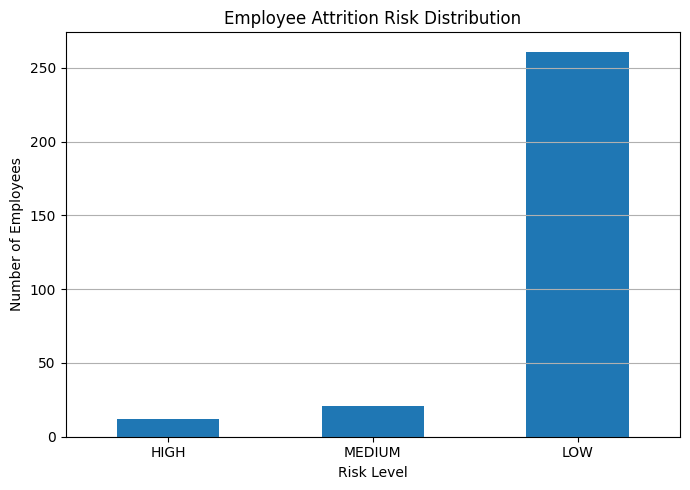

In [29]:
# ============================================================
# RISK DISTRIBUTION CHART
# ============================================================

risk_distribution.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# SAVE MODEL COMPARISON RESULTS
# ============================================================

MODEL_PATH.mkdir(
    parents=True,
    exist_ok=True
)

comparison_path = MODEL_PATH / "model_comparison_results.csv"

results_df.to_csv(
    comparison_path,
    index=False
)

print(f"✓ Saved: {comparison_path}")

✓ Saved: C:\Users\Shubham\Desktop\enterprise_hr_ai\models\model_comparison_results.csv


In [31]:
# ============================================================
# SAVE BEST MODEL
# ============================================================

best_model_path = MODEL_PATH / "best_attrition_model.joblib"

joblib.dump(
    best_model,
    best_model_path
)

print(f"✓ Best model saved: {best_model_path}")

✓ Best model saved: C:\Users\Shubham\Desktop\enterprise_hr_ai\models\best_attrition_model.joblib


In [32]:
# ============================================================
# SAVE BEST MODEL METRICS
# ============================================================

best_metrics_df = pd.DataFrame([{
    "Model": best_model_name,
    "Precision": best_metrics["Precision"],
    "Recall": best_metrics["Recall"],
    "F1": best_metrics["F1"],
    "ROC-AUC": best_metrics["ROC-AUC"]
}])

best_metrics_path = MODEL_PATH / "best_model_metrics.csv"

best_metrics_df.to_csv(
    best_metrics_path,
    index=False
)

print(f"✓ Saved: {best_metrics_path}")

✓ Saved: C:\Users\Shubham\Desktop\enterprise_hr_ai\models\best_model_metrics.csv


In [33]:
# ============================================================
# SAVE BEST MODEL PREDICTIONS
# ============================================================

PREDICTIONS_PATH = PROJECT_ROOT / "data" / "predictions"

PREDICTIONS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

predictions_path = (
    PREDICTIONS_PATH /
    "best_model_attrition_predictions.csv"
)

prediction_df.to_csv(
    predictions_path,
    index=False
)

print(f"✓ Saved: {predictions_path}")

✓ Saved: C:\Users\Shubham\Desktop\enterprise_hr_ai\data\predictions\best_model_attrition_predictions.csv


In [34]:
# ============================================================
# VERIFY SAVED ARTIFACTS
# ============================================================

files_to_check = [
    comparison_path,
    best_model_path,
    best_metrics_path,
    predictions_path
]

print("ARTIFACT VERIFICATION")
print("=" * 60)

for file_path in files_to_check:

    if file_path.exists():
        print(f"✓ {file_path}")

    else:
        print(f"✗ MISSING: {file_path}")

ARTIFACT VERIFICATION
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\models\model_comparison_results.csv
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\models\best_attrition_model.joblib
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\models\best_model_metrics.csv
✓ C:\Users\Shubham\Desktop\enterprise_hr_ai\data\predictions\best_model_attrition_predictions.csv


In [35]:
# ============================================================
# NOTEBOOK 08 FINAL SUMMARY
# ============================================================

print("=" * 70)
print("NOTEBOOK 08 — MODEL COMPARISON COMPLETE")
print("=" * 70)

print(f"\nModels evaluated:")
for name in trained_models:
    print(f"  ✓ {name}")

if not XGBOOST_AVAILABLE:
    print("  ⚠ XGBoost skipped due to environment/DLL issue.")

print(f"\n🏆 Best Model: {best_model_name}")
print(f"ROC-AUC: {best_auc:.4f}")

print("\nSaved Artifacts:")
print(f"  ✓ {comparison_path.name}")
print(f"  ✓ {best_model_path.name}")
print(f"  ✓ {best_metrics_path.name}")
print(f"  ✓ {predictions_path.name}")

print("\n" + "=" * 70)
print("READY FOR NOTEBOOK 09")
print("=" * 70)

NOTEBOOK 08 — MODEL COMPARISON COMPLETE

Models evaluated:
  ✓ Logistic Regression
  ✓ Random Forest
  ⚠ XGBoost skipped due to environment/DLL issue.

🏆 Best Model: Logistic Regression
ROC-AUC: 0.8182

Saved Artifacts:
  ✓ model_comparison_results.csv
  ✓ best_attrition_model.joblib
  ✓ best_model_metrics.csv
  ✓ best_model_attrition_predictions.csv

READY FOR NOTEBOOK 09
